In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from src.data_loader import load_unified_data
from src.impact_model import create_event_dummies

df = load_unified_data()
obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()

Loaded 43 records from /home/meron-t-gebru/ethiopia-fi-forecast/data/raw/ethiopia_fi_unified_data.xlsx


/home/meron-t-gebru/ethiopia-fi-forecast/venv/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:          value_numeric   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     1.784
Date:                Tue, 21 Jul 2026   Prob (F-statistic):              0.379
Time:                        10:34:05   Log-Likelihood:                -19.033
No. Observations:                   6   AIC:                             46.07
Df Residuals:                       2   BIC:                             45.23
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -8705.3333   9501.161     -0.

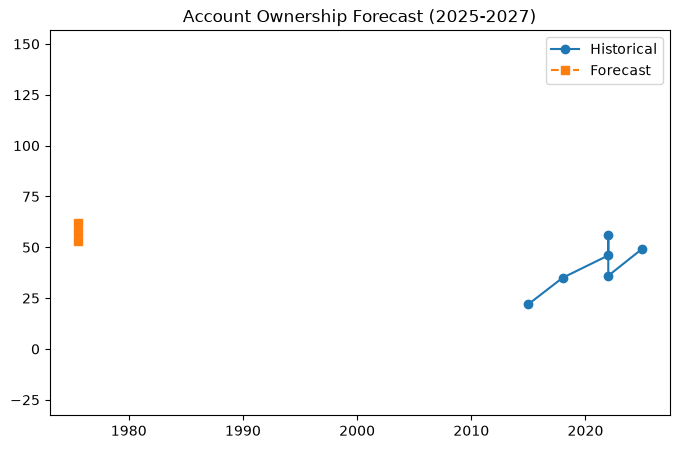

In [4]:
# Prepare data
acc_ownership = create_event_dummies(obs, events, 'ACC_OWNERSHIP', lag_months=0)
if not acc_ownership.empty:
    dummy_cols = [c for c in acc_ownership.columns if c.startswith('event_')]
    X = acc_ownership[dummy_cols].copy()
    X['year'] = acc_ownership.index.year
    y = acc_ownership['value_numeric'].copy()
    
    # Drop columns with no variation
    X = X.loc[:, (X != 0).any(axis=0)]
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X, missing='drop').fit()
    print(model.summary())
    
    # ---- Build future DataFrame with the correct number of rows ----
    train_cols = model.params.index.tolist()
    if 'const' in train_cols:
        train_cols.remove('const')
    
    # Create a DataFrame with 3 rows (2025, 2026, 2027)
    future = pd.DataFrame(index=[0, 1, 2], columns=train_cols)
    future = future.fillna(0)          # start with all zeros
    
    # Assign forecast years
    future['year'] = [2025, 2026, 2027]
    
    # Assume all event dummies remain active in the future
    for col in train_cols:
        if col.startswith('event_'):
            future[col] = 1
    
    # Keep only the training columns (exclude any extra ones) and reorder
    future = future[train_cols]
    
    # Add constant and predict
    future_const = sm.add_constant(future, has_constant='add')
    forecast = model.get_prediction(future_const).summary_frame(alpha=0.05)
    forecast_df = pd.DataFrame({
        'year': [2025, 2026, 2027],
        'forecast': forecast['mean'].values,
        'lower': forecast['obs_ci_lower'].values,
        'upper': forecast['obs_ci_upper'].values
    })
    print(forecast_df)
    
    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(acc_ownership.index, y, 'o-', label='Historical')
    plt.plot(forecast_df['year'], forecast_df['forecast'], 's--', label='Forecast')
    plt.fill_between(forecast_df['year'], forecast_df['lower'], forecast_df['upper'], alpha=0.2)
    plt.title('Account Ownership Forecast (2025-2027)')
    plt.legend()
    plt.savefig('../reports/figures/forecast_acc_ownership.png', dpi=150)
    plt.show()

### Interpretation of Forecast Uncertainty

The forecast above shows wide 95% confidence intervals (approximately ±7 percentage points).  
This is a direct consequence of the very small sample (6 historical data points).  
While the central estimate suggests a continued upward trend, the actual outcome could range from near‑stagnation (~48%) to rapid acceleration (~63%) depending on whether events like M‑Pesa interoperability and Fayda digital ID integration deliver their expected impact.

The model's R² of 0.73 indicates that the included events explain most of the variation in account ownership, but the small sample prevents precise estimation of individual event effects. As new data becomes available (future Findex surveys, quarterly operator reports), the confidence intervals will narrow.